## Complete project

In [3]:
#!/usr/bin/env python3
#Imports
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

AUC: 0.6600


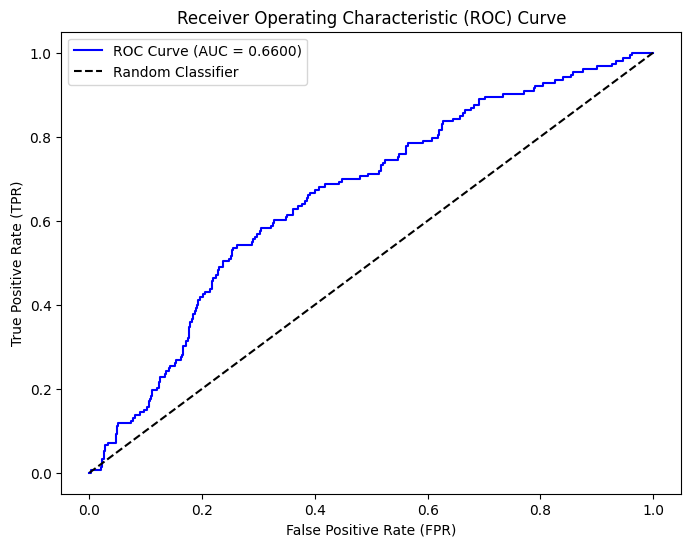

In [5]:
def main():
    #Read all datasets
    df_payments = pd.read_csv("data/payments.csv")
    df_merchants = pd.read_csv("data/merchants.csv")
    df_buyers = pd.read_csv("data/buyers.csv")
    
    #Determine the is_fraud label based on chargeback timestamp
    df_payments['is_fraud'] = df_payments['chargeback_timestamp'].notna().astype(int)
    
    # Merge the result with merchants (ensure correct column names are used)
    merged = pd.merge(df_payments, df_merchants, left_on='merchant_id', right_on='id', how='left')
    
    # Merge payments with buyers
    merged = pd.merge(merged, df_buyers, left_on='buyer_id', right_on='id', how='left')
    
    # Drop the redundant 'id' column from merchants (if it exists)
    if 'id' in merged.columns:
        merged.drop(columns=['id'], inplace=True)
        
    # Rename columns
    merged = merged.rename(
        columns={'country_x': 'merchant_country',
                 'country_y': 'buyer_country',
                 'category': 'merchant_category'}
    )

    #Dropping redundant columns
    merged = merged.drop(columns=['id_x', 'id_y'])
    
    # Convert timestamp to datetime and sort
    merged['transaction_timestamp'] = pd.to_datetime(merged['transaction_timestamp'])

    #sorting
    merged_sorted = merged.sort_values('transaction_timestamp').reset_index(drop=True)
    
    #Calculate Merchant fraud rate
    merged_sorted['merchant_fraud_rate'] = (
        merged_sorted.groupby('merchant_id')['is_fraud']
        .expanding().mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )
    merged_sorted['merchant_fraud_rate'] = merged_sorted['merchant_fraud_rate'].fillna(0)
    
    #Calculate Buyer fraud rate
    merged_sorted['buyer_fraud_rate'] = (
        merged_sorted.groupby('buyer_id')['is_fraud']
        .expanding().mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )
    merged_sorted['buyer_fraud_rate'] = merged_sorted['buyer_fraud_rate'].fillna(0)
    
    merged_sorted["transaction_date"] = pd.to_datetime(merged_sorted["transaction_timestamp"]).dt.date
    
    #One hot encoding categorical features
    merged_encoded = pd.get_dummies(merged_sorted,columns=
                                ["merchant_category",
                                 "merchant_country", "buyer_country"])
    # Constants from part 1: ground truth available after 32 days
    L_DAYS = 32
    TEST_WINDOW_DAYS = 30  # a month's worth of data
    
    # Find the latest payment transaction date in the dataset
    most_recent_trx_date = merged_encoded["transaction_date"].max()
    # Calculate the end of the test set as the latest timestamp minus ground truth lag
    test_end = most_recent_trx_date - pd.Timedelta(days=L_DAYS)
    # Calculate the start of the test set as 30 days before test_end
    test_start = test_end - pd.Timedelta(days=TEST_WINDOW_DAYS)
    #Training data must end L_DAYS before the test set starts to ensure ground truth is known
    training_end = test_start - pd.Timedelta(days = L_DAYS)
    
    # Split the data into training and test sets
    train = merged_encoded[merged_encoded["transaction_date"] <= training_end]
    test = merged_encoded[(merged_encoded["transaction_date"] >= test_start)
                         & (merged_encoded["transaction_date"] <= test_end)]    
    
    #Prepare features and target
    X_train = train.drop(columns=['buyer_id','transaction_timestamp',
                                  'chargeback_timestamp',
                                  "is_fraud","merchant_id", "transaction_date"])
    y_train = train["is_fraud"]

    #Test dataset
    X_test = test.drop(columns=['buyer_id','transaction_timestamp',
                                  'chargeback_timestamp',
                                  "is_fraud","merchant_id", "transaction_date"])
    y_test = test["is_fraud"]
    
    # Scale features (for models like Logistic Regression)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train the model
    model = LogisticRegression(class_weight="balanced", max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    # Predict and calculate AUC
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC: {auc:.4f}")
    
    # Compute ROC curve values
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', color='blue')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')  # Diagonal line
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()
    
if __name__ == "__main__":
    main()